In [1]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import date
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline, splev, splrep

from plot_outputs import *

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.stics_io import read_sti_file, get_stics_data, stics_output
from openalea.archicrop.cereal_axis import bell_shaped_dist, geometric_dist
from openalea.archicrop.cereal_leaf import sr_dornbush
from openalea.archicrop.growth import demand_dist, equal_dist, dev_dist, demand_dist_bis
from openalea.archicrop.viability import resolve_organ_growth, compute_skew

from ipywidgets import interact, interactive, IntSlider, FloatSlider, fixed, Play, HBox, VBox, jslink

In [2]:
distribution_function = demand_dist_bis

In [3]:
tec_file='D:/ArchiCrop/data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plant_file='D:/ArchiCrop/data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='D:/ArchiCrop/data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
stics_output_file_pot='D:/ArchiCrop/data/usms_STICS/v10/mod_s02NT18SorgV2D1_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)

dae = range(len(thermal_time))

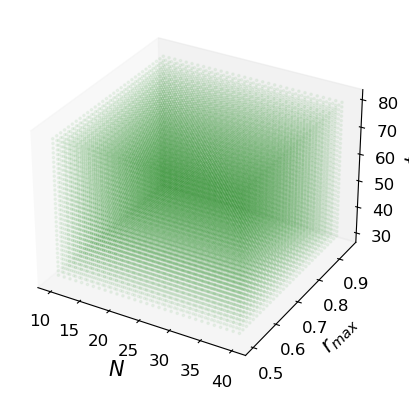

In [4]:
phi_bounds = [30,80]
rmax_bounds = [0.5,0.95]

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(min(rmax_bounds), max(rmax_bounds), len(p1))
p3 = np.linspace(min(phi_bounds), max(phi_bounds), len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='green', alpha=0.05)

ax.set_xlabel(r"$N$", fontsize=15)
ax.set_ylabel(r"$r_{max}$", fontsize=15)
ax.set_zlabel(r"$\phi$", fontsize=15)
ax.tick_params(labelsize=12)

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_all.png", dpi=1000)
plt.show()


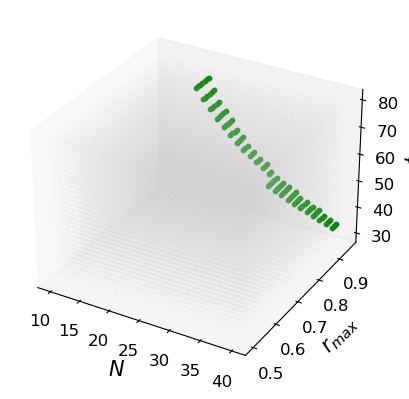

In [5]:
phi_bounds = [30,80]
rmax_bounds = [0.5,0.95]

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(min(rmax_bounds), max(rmax_bounds), len(p1))
p3 = np.linspace(min(phi_bounds), max(phi_bounds), len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='lightgrey', alpha=0.05)

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

phi = {n : compute_phi(n, end_veg_pot) for n in p1}
rmax = {n : compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)
        for n in p1
       }

d = {n: [(phi[n], r) for r in rmax[n] if min(phi_bounds) <= phi[n] <= max(phi_bounds) and min(rmax_bounds) <= r <= max(rmax_bounds)] for n in p1}

for n,l in d.items():
    for p,r in l:
        ax.scatter(
            n, r, p, s=10, c='green', alpha=1
        )

ax.set_xlabel(r"$N$", fontsize=15)
ax.set_ylabel(r"$r_{max}$", fontsize=15)
ax.set_zlabel(r"$\phi$", fontsize=15)
ax.tick_params(labelsize=12)

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_constrained.png")
plt.show()


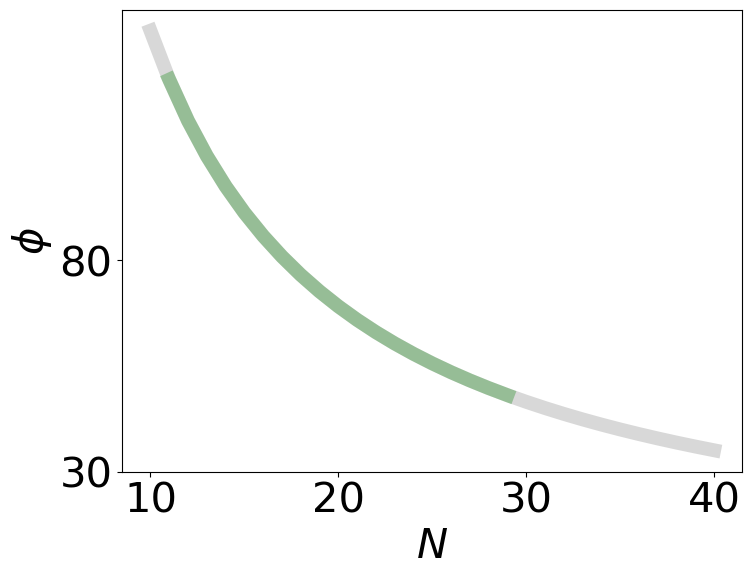

In [6]:
phi_bounds = [30,80]
rmax_bounds = [0.5,0.95]

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(min(rmax_bounds), max(rmax_bounds), len(p1))
p3 = np.linspace(min(phi_bounds), max(phi_bounds), len(p1))

fig = plt.figure(figsize=(8,6)) 
ax = fig.add_subplot()

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

phi = {n : compute_phi(n, end_veg_pot) for n in p1}
# rmax = {n : compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)
#         for n in p1
#        }

# d = {n: [(phi[n], r) for r in rmax[n] if min(phi_bounds) <= phi[n] <= max(phi_bounds) and min(rmax_bounds) <= r <= max(rmax_bounds)] for n in p1}

start = 1
end = 20
ax.plot(p1, list(phi.values()), linewidth=10, color='gray', alpha=0.3)
ax.plot(p1[start:end], list(phi.values())[start:end], linewidth=10, color='green', alpha=0.3)

ax.set_xlabel(r"$N$", fontsize=30)
ax.set_ylabel(r"$\phi$", fontsize=30)
ax.set_xticks([10,20,30,40])
ax.set_yticks([30,80])
ax.tick_params(labelsize=30)

# ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_N_phi.png", dpi=1000)
plt.show()


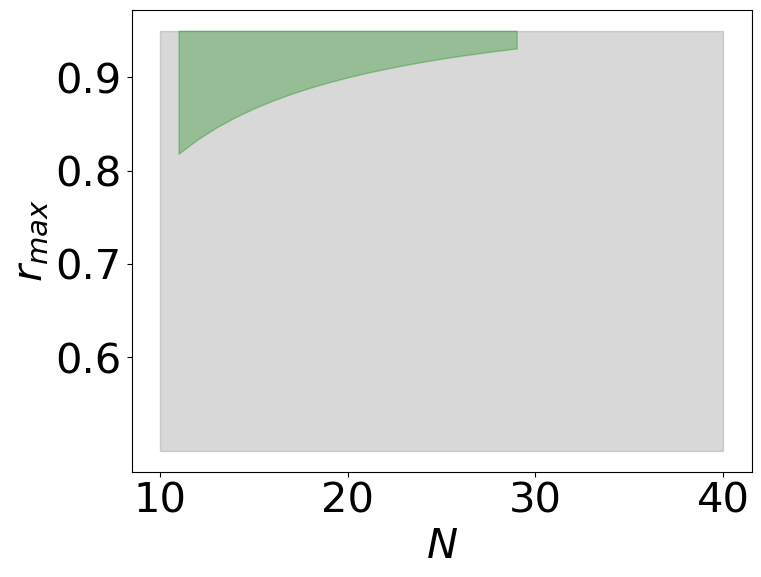

In [7]:
phi_bounds = [30,80]
rmax_bounds = [0.5,0.95]

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(min(rmax_bounds), max(rmax_bounds), len(p1))
p3 = np.linspace(min(phi_bounds), max(phi_bounds), len(p1))

fig = plt.figure(figsize=(8,6)) 
ax = fig.add_subplot()

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

phi = {n : compute_phi(n, end_veg_pot) for n in p1}
rmax = {n : compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)
        for n in p1
       }

# d = {n: [(phi[n], r) for r in rmax[n] if min(phi_bounds) <= phi[n] <= max(phi_bounds) and min(rmax_bounds) <= r <= max(rmax_bounds)] for n in p1}

start = 1
end = 20
# ax.plot(p1, list(rmax.values()), linewidth=10, color='gray', alpha=0.3
ax.fill_between(p1, 
                [min(rmax_bounds)]*len(p1), 
                [max(rmax_bounds)]*len(p1), 
                color='gray', alpha=0.3)
ax.fill_between(p1[start:end], 
                [min(r) for r in list(rmax.values())[start:end]], 
                [min(max(rmax_bounds),max(r)) for r in list(rmax.values())[start:end]], 
                color='green', alpha=0.3)

ax.set_xlabel(r"$N$", fontsize=30)
ax.set_ylabel(r"$r_{max}$", fontsize=30)
ax.set_xticks([10,20,30,40])
ax.set_yticks([0.6,0.7,0.8,0.9])
ax.tick_params(labelsize=30)

# ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_N_rmax.png", dpi=1000)
plt.show()


In [8]:
d

{np.int64(10): [],
 np.int64(11): [],
 np.int64(12): [],
 np.int64(13): [],
 np.int64(14): [],
 np.int64(15): [],
 np.int64(16): [],
 np.int64(17): [],
 np.int64(18): [(np.float64(76.5598440860215), np.float64(0.8888888888888888)),
  (np.float64(76.5598440860215), np.float64(0.8988888888888888)),
  (np.float64(76.5598440860215), np.float64(0.9088888888888889)),
  (np.float64(76.5598440860215), np.float64(0.9188888888888889)),
  (np.float64(76.5598440860215), np.float64(0.9288888888888889)),
  (np.float64(76.5598440860215), np.float64(0.9388888888888889)),
  (np.float64(76.5598440860215), np.float64(0.9488888888888889))],
 np.int64(19): [(np.float64(72.65372959183672),
   np.float64(0.8947368421052632)),
  (np.float64(72.65372959183672), np.float64(0.9047368421052632)),
  (np.float64(72.65372959183672), np.float64(0.9147368421052632)),
  (np.float64(72.65372959183672), np.float64(0.9247368421052632)),
  (np.float64(72.65372959183672), np.float64(0.9347368421052632)),
  (np.float64(72.65

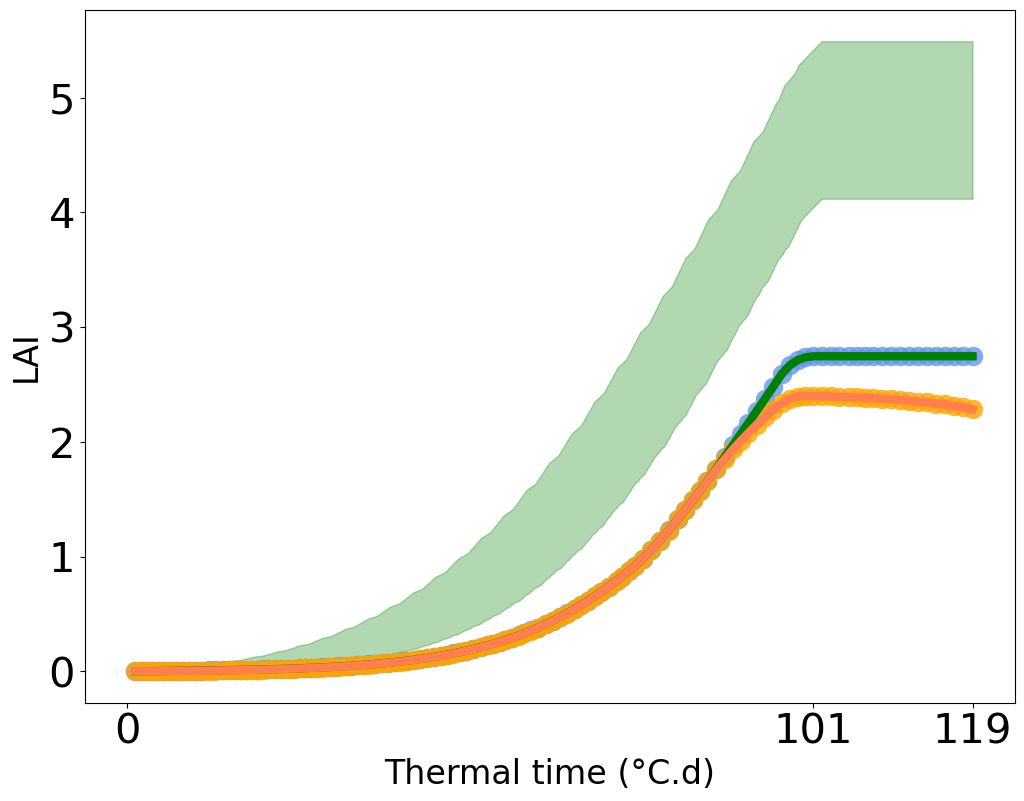

In [9]:
from openalea.archicrop.cereal_axis import bell_shaped_dist
from openalea.archicrop.viability import resolve_organ_growth, compute_skew
import math

leaf_area_plant_pot_grow = leaf_area_plant_pot[:index_end_veg_pot+2]
thermal_time_pot_grow = thermal_time_pot[:index_end_veg_pot+2]
spl = splrep(thermal_time_pot, leaf_area_plant_pot)

fig, ax1 = plt.subplots(figsize=(12, 9))

first = True
mins = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))
maxs = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))

for n,l in d.items():
    for p,r in l:
        ligulochron = p * 1.6
        starts = []
        ends = []
        for i in range(n):
            start = i * p
            end = start + ligulochron
            starts.append(start)
            ends.append(end)
        
        la_starts = splev(starts, spl)
        la_ends = splev(ends, spl)
        
        leaf_areas,_,_,_ = resolve_organ_growth(n, 1.6, la_ends)
        leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
        skews = []
        for rank in range(1, n+1):
            if r != rank/n and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=n, rmax=r, leaf_areas=leaf_areas_norm)
                if -10 < skew < 0:
                    skews.append(skew)
    
        for pot_factor in [1.0,1.25,1.5,1.75,2]:
            
            shapes = []
            for skew in skews:
                bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant_pot[-1] * pot_factor, n, r, skew)
                viable = True
                for i,bs in enumerate(bell_shaped_leaf_areas):
                    if bs < leaf_areas[i]: 
                        viable = False
                        break
                if viable:
                    shapes.append(bell_shaped_leaf_areas)
            
            for j,shape in enumerate(shapes):
                S = []
                tt = np.arange(max(ends))
                # print(len(tt))
                for k,t in enumerate(tt):
                    sum_temp = 0
                    for i,(s,e) in enumerate(zip(starts,ends)):
                        if s <= t < e:
                            sum_temp += (t-s)/(e-s) * shape[i]
                        elif t >= e:
                            sum_temp += shape[i]
                    if sum_temp < mins[k] or mins[k] == 0:
                        mins[k] = sum_temp
                    if sum_temp > maxs[k]:
                        maxs[k] = sum_temp
                    S.append(sum_temp)
            
                # if first:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2, label="Viable")
                #     first = False
                # else:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2)

ax1.fill_between(np.concatenate((tt,np.array(thermal_time_pot[index_end_veg_pot+2:]))), 
                 [m*density/100**2 for m in mins]+[max(mins)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 [m*density/100**2 for m in maxs]+[max(maxs)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 alpha = 0.3, color='green')

ax1.scatter(thermal_time, [la*density/100**2 for la in leaf_area_plant_pot], linewidth=8, alpha=0.8, color="cornflowerblue")
ax1.plot(thermal_time, [la*density/100**2 for la in leaf_area_plant_pot], linewidth=6, color="green")
ax1.scatter(thermal_time, [(la-sen)*density/100**2 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="orange", linewidth=8, alpha=0.8)
ax1.plot(thermal_time, [(la-sen)*density/100**2 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="coral", linewidth=6)

ax1.set_xlabel("Thermal time (°C.d)", fontsize=24)
ax1.set_ylabel("LAI", fontsize=24)
ax1.set_xticks([0,end_veg,max(thermal_time)], [0,index_end_veg,119])
# ax1.legend(fontsize=15)
ax1.tick_params(labelsize=30)


today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/result_2_viable_morphospace_dynamics.png", dpi=1000)
plt.show()

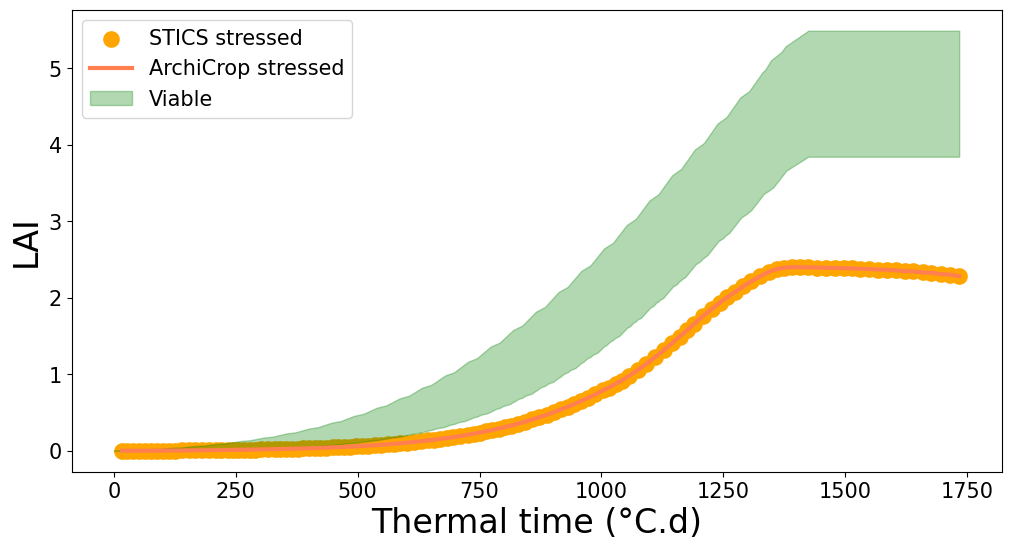

In [10]:
from openalea.archicrop.cereal_axis import bell_shaped_dist
from openalea.archicrop.viability import resolve_organ_growth, compute_skew
import math
import matplotlib.pyplot as plt

leaf_area_plant_pot_grow = leaf_area_plant_pot[:index_end_veg_pot+2]
thermal_time_pot_grow = thermal_time_pot[:index_end_veg_pot+2]
spl = splrep(thermal_time_pot, leaf_area_plant_pot)

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.scatter(thermal_time, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="orange", linewidth=6, label='STICS stressed')
plt.plot(thermal_time, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="coral", linewidth=3, label='ArchiCrop stressed')

first = True
mins = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))
maxs = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))

for n,l in d.items():
    for p,r in l:
        ligulochron = p * 1.6
        starts = []
        ends = []
        for i in range(n):
            start = i * p
            end = start + ligulochron
            starts.append(start)
            ends.append(end)
        
        la_starts = splev(starts, spl)
        la_ends = splev(ends, spl)
        
        leaf_areas,_,_,_ = resolve_organ_growth(n, 1.6, la_ends)
        leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
        skews = []
        for rank in range(1, n+1):
            if r != rank/n and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=n, rmax=r, leaf_areas=leaf_areas_norm)
                if -10 < skew < 0:
                    skews.append(skew)
    
        for pot_factor in [1.0,1.1,1.2,1.3,1.4,1.5,2]:
            
            shapes = []
            for skew in skews:
                bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant_pot[-1] * pot_factor, n, r, skew)
                viable = True
                for i,bs in enumerate(bell_shaped_leaf_areas):
                    if bs < leaf_areas[i]: 
                        viable = False
                        break
                if viable:
                    shapes.append(bell_shaped_leaf_areas)
            
            for j,shape in enumerate(shapes):
                S = []
                tt = np.arange(max(ends))
                # print(len(tt))
                for k,t in enumerate(tt):
                    sum_temp = 0
                    for i,(s,e) in enumerate(zip(starts,ends)):
                        if s <= t < e:
                            sum_temp += (t-s)/(e-s) * shape[i]
                        elif t >= e:
                            sum_temp += shape[i]
                    if sum_temp < mins[k] or mins[k] == 0:
                        mins[k] = sum_temp
                    if sum_temp > maxs[k]:
                        maxs[k] = sum_temp
                    S.append(sum_temp)
            
                # if first:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2, label="Viable")
                #     first = False
                # else:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2)

ax1.fill_between(np.concatenate((tt,np.array(thermal_time_pot[index_end_veg_pot+2:]))), 
                 [m*density/100**2 for m in mins]+[max(mins)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 [m*density/100**2 for m in maxs]+[max(maxs)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 alpha = 0.3, color='green', label="Viable")
ax1.set_xlabel("Thermal time (°C.d)", fontsize=24)
ax1.set_ylabel("LAI", fontsize=24)
ax1.legend(fontsize=15)
ax1.tick_params(labelsize=15)


today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/result_2_viable_morphospace_dynamics.png", dpi=1000)
plt.show()

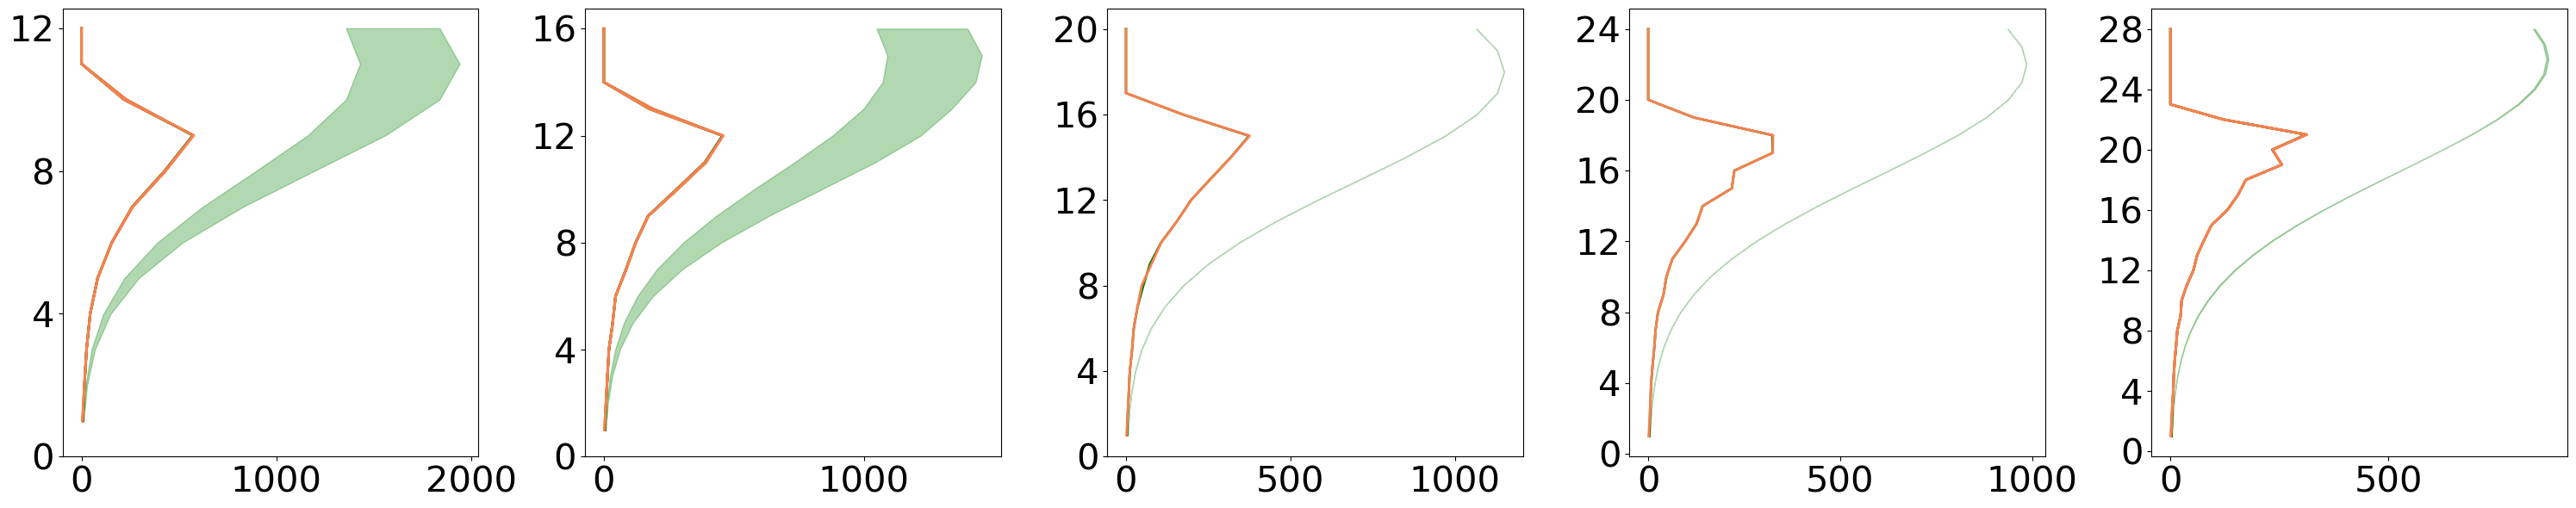

In [11]:
def leaf_growth_and_pot(N, ligul_factor, rate=False):

    fig, ax = plt.subplots(1, len(N), figsize=(6*len(N), 6))

    first = True

    for k, nb_phy in enumerate(N):
        mins = np.zeros(nb_phy)
        maxs = np.zeros(nb_phy)
        for pot_factor in [1.0,1.1,1.2,1.3,1.4,1.5,2]:
            for pot in [True, False]:
                if pot:
                    stics_output_file='D:/ArchiCrop/data/usms_STICS/v10/mod_s02NT18SorgV2D1_no_stress.sti'
                    color_stics = "cornflowerblue"
                    label_stics = "STICS unstressed"
                    color_archicrop = "green"
                    label_archicrop = "ArchiCrop unstressed"
                    label_viable = "Viable unstressed"
                else:
                    stics_output_file='D:/ArchiCrop/data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
                    color_stics = "orange"
                    label_stics = "STICS stressed"
                    color_archicrop = "coral"
                    label_archicrop = "ArchiCrop stressed"
                    label_viable = "Viable stressed"
                density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)

                if pot:
                    pot_leaf_area = pot_factor * max(leaf_area_plant)
                    # nb_phy = math.floor((end_veg-thermal_time[0]-ligulochron)/phyllochron)
                    phyllochron = (end_veg)/(nb_phy - 1 + ligul_factor)
                    ligulochron = phyllochron * ligul_factor
                
                    leaf_area_plant = leaf_area_plant[:index_end_veg+2]
                    thermal_time = thermal_time[:index_end_veg+2]
                    # end_veg = thermal_time[index_end_veg+1]
                    spl = splrep(thermal_time, leaf_area_plant)
                 
                    starts = []
                    ends = []
                
                    for i in range(nb_phy):
                        start = i * phyllochron
                        end = start + ligulochron
                        
                        starts.append(start)
                        ends.append(end)
            
                    la_starts = splev(starts, spl)
                    la_ends = splev(ends, spl)
                    leaf_areas,_,_,_ = resolve_organ_growth(nb_phy, ligul_factor, la_ends)
        
                    S = []
                    tt = np.arange(max(ends))
                    for t in tt:
                        sum_temp = 0
                        for i,(s,e) in enumerate(zip(starts,ends)):
                            if s <= t < e:
                                sum_temp += (t-s)/(e-s) * leaf_areas[i]
                            elif t >= e:
                                sum_temp += leaf_areas[i]
                        S.append(sum_temp)
                       
                    for i, la in enumerate(leaf_areas):
                        if la == max(leaf_areas):
                            id_max = i+1
                            break
                
                    rmax_int = np.arange(max(0.5,(id_max-1)/nb_phy), min(0.95,(id_max+1)/nb_phy), 0.05)
                   
                    leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
                
                    skews_rmax = {}
                    id = 0
                    for rank in range(1, nb_phy+1):
                        for rmax in rmax_int:
                            if rmax != rank/nb_phy and leaf_areas[rank-1] > 0:
                                skew = compute_skew(rank=rank, nb_phy=nb_phy, rmax=rmax, leaf_areas=leaf_areas_norm)
                                if -10 < skew < 0:
                                    skews_rmax[id] = (skew, rmax)
                                    id += 1
        
                    shapes = []
                    for id, (skew,rmax) in list(skews_rmax.items()):
                        bell_shaped_leaf_areas = bell_shaped_dist(pot_leaf_area, nb_phy, rmax, skew)
                        viable = True
                        for i,bs in enumerate(bell_shaped_leaf_areas):
                            if bs < leaf_areas[i]: 
                                viable = False
                                del skews_rmax[id]
                                break
                        if viable:
                            shapes.append(bell_shaped_leaf_areas)
    
                    if len(shapes) > 0:
                        shapes = np.array(shapes)
                        mins = np.array([new if new < old or old == 0 else old for old, new in zip(mins, shapes.min(axis=0))])
                        maxs = np.array([new if new > old or old == 0 else old for old, new in zip(maxs, shapes.max(axis=0))])
            
                mtgs = {}
                for id,(skew,rmax) in skews_rmax.items():
                    plant = ArchiCrop(daily_dynamics=daily_dynamics, leaf_area=pot_leaf_area, height=max(height_canopy)*pot_factor, 
                                        nb_phy=nb_phy, phyllochron=phyllochron, leaf_duration=ligul_factor, rmax=rmax, skew=skew)
                    plant.generate_potential_plant()
                    growing_plant = plant.grow_plant(rate=False, distribution_function=distribution_function)
                    growing_plant_mtg = list(growing_plant.values())
                    mtgs[id] = growing_plant_mtg
    
                for id in mtgs:
                    visible_leaf_areas = []
                    for leaf in mtgs[id][80].properties()["visible_leaf_area"]:
                        visible_leaf_areas.append(mtgs[id][80].properties()["visible_leaf_area"][leaf])
                    if first and len(visible_leaf_areas) > 0:
                        ax[k].plot(visible_leaf_areas, range(1, nb_phy + 1), linewidth=2, color=color_archicrop, label=label_archicrop)
                        first = False
                    else:
                        ax[k].plot(visible_leaf_areas, range(1, nb_phy + 1), linewidth=2, color=color_archicrop)

        if first:
            ax[k].fill_betweenx(range(1,len(mins)+1), mins, maxs, color="green", alpha=0.3, label=label_viable)
        else:
            ax[k].fill_betweenx(range(1,len(mins)+1), mins, maxs, color="green", alpha=0.3)
        
        ax[k].set_yticks(np.arange(0,nb_phy+1,4))
        ax[k].tick_params(labelsize=30)
            
        
    # ax[-1].set_xlabel("Leaf surface (cm²)", fontsize=24)
    # ax[2].set_ylabel("Leaf rank", fontsize=24)
    # ax[len(N)-1].legend(fontsize=14, loc="lower right")

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
    plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/leaf_growth_all_N_{nb_phy}_pot_factor_{pot_factor}_rate_{rate}.png", dpi=1000)
    plt.show()

N = [12,16,20,24,28]
ligul_factor = 1.6
leaf_growth_and_pot(N, ligul_factor, rate=False)

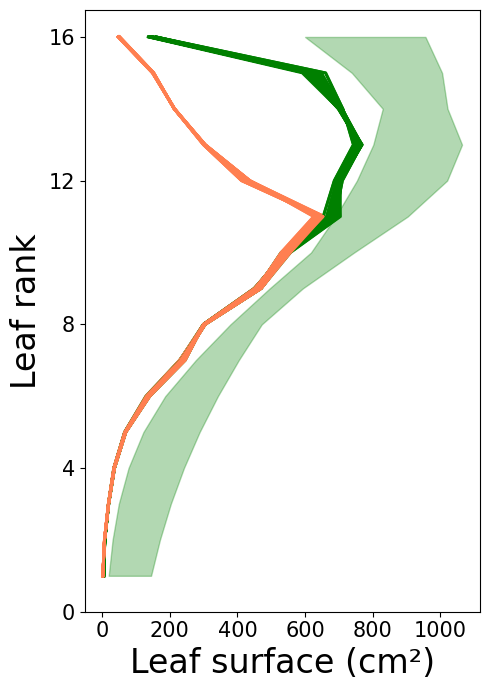

In [ ]:
def leaf_growth_and_pot(N, ligul_factor, rate=False):

    fig, ax = plt.subplots(1, len(N), figsize=(5*len(N), 7))

    first = True

    for k, nb_phy in enumerate(N):
        mins = np.zeros(nb_phy)
        maxs = np.zeros(nb_phy)
        for pot_factor in [1.0,1.1,1.2,1.3,1.4,1.5,2]:
            for pot in [True, False]:
                if pot:
                    stics_output_file='D:/ArchiCrop/data/usms_STICS/v10/mod_s02NT18SorgV2D1_no_stress.sti'
                    color_stics = "cornflowerblue"
                    label_stics = "STICS unstressed"
                    color_archicrop = "green"
                    label_archicrop = "ArchiCrop unstressed"
                    label_viable = "Viable unstressed"
                else:
                    stics_output_file='D:/ArchiCrop/data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
                    color_stics = "orange"
                    label_stics = "STICS stressed"
                    color_archicrop = "coral"
                    label_archicrop = "ArchiCrop stressed"
                    label_viable = "Viable stressed"
                density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)

                if pot:
                    pot_leaf_area = pot_factor * max(leaf_area_plant)
                    # nb_phy = math.floor((end_veg-thermal_time[0]-ligulochron)/phyllochron)
                    phyllochron = (end_veg)/(nb_phy - 1 + ligul_factor)
                    ligulochron = phyllochron * ligul_factor
                
                    leaf_area_plant = leaf_area_plant[:index_end_veg+2]
                    thermal_time = thermal_time[:index_end_veg+2]
                    end_veg = thermal_time[index_end_veg+1]
                    spl = splrep(thermal_time, leaf_area_plant)
                 
                    starts = []
                    ends = []
                
                    for i in range(nb_phy):
                        start = i * phyllochron
                        end = start + ligulochron
                        
                        starts.append(start)
                        ends.append(end)
            
                    la_starts = splev(starts, spl)
                    la_ends = splev(ends, spl)
                    leaf_areas,_,_,_ = resolve_organ_growth(nb_phy, ligul_factor, la_ends)
        
                    S = []
                    tt = np.arange(max(ends))
                    for t in tt:
                        sum_temp = 0
                        for i,(s,e) in enumerate(zip(starts,ends)):
                            if s <= t < e:
                                sum_temp += (t-s)/(e-s) * leaf_areas[i]
                            elif t >= e:
                                sum_temp += leaf_areas[i]
                        S.append(sum_temp)
                       
                    for i, la in enumerate(leaf_areas):
                        if la == max(leaf_areas):
                            id_max = i+1
                            break
                
                    rmax_int = np.arange(max(0.5,(id_max-1)/nb_phy), min(0.95,(id_max+1)/nb_phy), 0.05)
                   
                    leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
                
                    skews_rmax = {}
                    id = 0
                    for rank in range(1, nb_phy+1):
                        for rmax in rmax_int:
                            if rmax != rank/nb_phy and leaf_areas[rank-1] > 0:
                                skew = compute_skew(rank=rank, nb_phy=nb_phy, rmax=rmax, leaf_areas=leaf_areas_norm)
                                if -10 < skew < 0:
                                    skews_rmax[id] = (skew, rmax)
                                    id += 1
        
                    shapes = []
                    for id, (skew,rmax) in list(skews_rmax.items()):
                        bell_shaped_leaf_areas = bell_shaped_dist(pot_leaf_area, nb_phy, rmax, skew)
                        viable = True
                        for i,bs in enumerate(bell_shaped_leaf_areas):
                            if bs < leaf_areas[i]: 
                                viable = False
                                del skews_rmax[id]
                                break
                        if viable:
                            shapes.append(bell_shaped_leaf_areas)
    
                    if len(shapes) > 0:
                        shapes = np.array(shapes)
                        mins = np.array([new if new < old or old == 0 else old for old, new in zip(mins, shapes.min(axis=0))])
                        maxs = np.array([new if new > old or old == 0 else old for old, new in zip(maxs, shapes.max(axis=0))])
            
                mtgs = {}
                for id,(skew,rmax) in skews_rmax.items():
                    plant = ArchiCrop(daily_dynamics=daily_dynamics, leaf_area=pot_leaf_area, height=max(height_canopy)*pot_factor, 
                                        nb_phy=nb_phy, phyllochron=phyllochron, leaf_duration=ligul_factor, rmax=rmax, skew=skew)
                    plant.generate_potential_plant()
                    growing_plant = plant.grow_plant(rate=False, distribution_function=distribution_function)
                    growing_plant_mtg = list(growing_plant.values())
                    mtgs[id] = growing_plant_mtg
    
                for id in mtgs:
                    visible_leaf_areas = []
                    for leaf in mtgs[id][80].properties()["visible_leaf_area"]:
                        visible_leaf_areas.append(mtgs[id][80].properties()["visible_leaf_area"][leaf])
                    if first and len(visible_leaf_areas) > 0:
                        ax.plot(visible_leaf_areas, range(1, nb_phy + 1), linewidth=2, color=color_archicrop, label=label_archicrop)
                        first = False
                    else:
                        ax.plot(visible_leaf_areas, range(1, nb_phy + 1), linewidth=2, color=color_archicrop)

        if first:
            ax.fill_betweenx(range(1,len(mins)+1), mins, maxs, color="green", alpha=0.3, label=label_viable)
        else:
            ax.fill_betweenx(range(1,len(mins)+1), mins, maxs, color="green", alpha=0.3)
        
        ax.set_yticks(np.arange(0,nb_phy+1,4))
        ax.tick_params(labelsize=15)
            
        
    ax.set_xlabel("Leaf surface (cm²)", fontsize=24)
    ax.set_ylabel("Leaf rank", fontsize=24)
    # ax[len(N)-1].legend(fontsize=14, loc="lower right")

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
    plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/leaf_growth_all_N_{nb_phy}_pot_factor_{pot_factor}_rate_{rate}.png", dpi=1000)
    plt.show()

N = [16]
ligul_factor = 1.6
leaf_growth_and_pot(N, ligul_factor, rate=False)

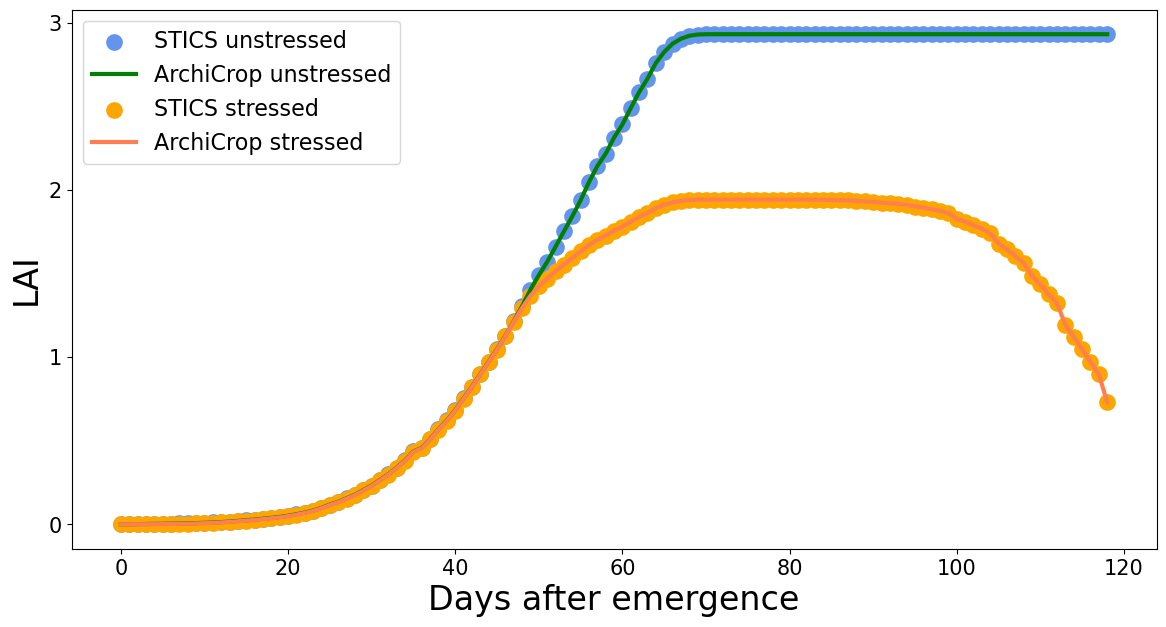

In [12]:
fig = plt.figure(figsize=(14, 7))
# plt.plot(thermal_time[:index_end_veg+2], leaf_area_plant[:index_end_veg+2], color="black")
plt.scatter(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant_pot, sen_leaf_area_plant_pot)], color="cornflowerblue", linewidth=6, label='STICS unstressed')
plt.plot(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant_pot, sen_leaf_area_plant_pot)], color="green", linewidth=3, label='ArchiCrop unstressed')
plt.scatter(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="orange", linewidth=6, label='STICS stressed')
plt.plot(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="coral", linewidth=3, label='ArchiCrop stressed')
plt.xlabel("Days after emergence", fontsize=24)
plt.ylabel("LAI", fontsize=24)
plt.yticks([0,1,2,3])
plt.legend(fontsize=16)
plt.tick_params(labelsize=15)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/LAI_stressed_and_not.png", dpi=1000)
plt.show()

In [24]:
import time
import sys
sys.path.append("../data") 
from archi_dict import archi_sorghum as archi

archi['nb_tillers'] = 0
archi['leaf_area'] = max(height_canopy_pot)*pot_factor
archi['height'] = max(leaf_area_plant_pot)*pot_factor
pot_factor = 1.5

start = time.time()
plant = ArchiCrop(daily_dynamics=daily_dynamics, **archi)
plant.generate_potential_plant()
growing_plant = plant.grow_plant(rate=False, distribution_function=distribution_function)
end = time.time()
print(f"Time for 1 simulation of {len(growing_plant)} days: {end-start}")

Time for 1 simulation of 119 days: 3.5380165576934814
